In [1]:
import pandas as pd

from sklearn.datasets import load_wine

from sklearn.model_selection import train_test_split

from sklearn.naive_bayes import GaussianNB
from sklearn.naive_bayes import MultinomialNB

from sklearn.metrics import confusion_matrix

import seaborn as sn
import matplotlib.pyplot as plt

In [2]:
wine = load_wine()

print(dir(wine))

['DESCR', 'data', 'feature_names', 'frame', 'target', 'target_names']


In [3]:
df = pd.DataFrame(
    wine.data,
    columns=wine.feature_names
)

print(df.head())

   alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  \
0    14.23        1.71  2.43               15.6      127.0           2.80   
1    13.20        1.78  2.14               11.2      100.0           2.65   
2    13.16        2.36  2.67               18.6      101.0           2.80   
3    14.37        1.95  2.50               16.8      113.0           3.85   
4    13.24        2.59  2.87               21.0      118.0           2.80   

   flavanoids  nonflavanoid_phenols  proanthocyanins  color_intensity   hue  \
0        3.06                  0.28             2.29             5.64  1.04   
1        2.76                  0.26             1.28             4.38  1.05   
2        3.24                  0.30             2.81             5.68  1.03   
3        3.49                  0.24             2.18             7.80  0.86   
4        2.69                  0.39             1.82             4.32  1.04   

   od280/od315_of_diluted_wines  proline  
0                  

In [4]:
df['target'] = wine.target

print(df.head())

   alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  \
0    14.23        1.71  2.43               15.6      127.0           2.80   
1    13.20        1.78  2.14               11.2      100.0           2.65   
2    13.16        2.36  2.67               18.6      101.0           2.80   
3    14.37        1.95  2.50               16.8      113.0           3.85   
4    13.24        2.59  2.87               21.0      118.0           2.80   

   flavanoids  nonflavanoid_phenols  proanthocyanins  color_intensity   hue  \
0        3.06                  0.28             2.29             5.64  1.04   
1        2.76                  0.26             1.28             4.38  1.05   
2        3.24                  0.30             2.81             5.68  1.03   
3        3.49                  0.24             2.18             7.80  0.86   
4        2.69                  0.39             1.82             4.32  1.04   

   od280/od315_of_diluted_wines  proline  target  
0          

In [5]:
X = df.drop('target', axis='columns')

y = df.target

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=10
)

In [7]:
model_g = GaussianNB()

model_g.fit(X_train, y_train)

GaussianNB()

In [8]:
gaussian_accuracy = model_g.score(
    X_test,
    y_test
)

In [9]:
print("\nGaussianNB Accuracy:")

print(gaussian_accuracy)


GaussianNB Accuracy:
0.8888888888888888


In [10]:
y_predicted_g = model_g.predict(X_test)

print("\nGaussian Predictions:")

print(y_predicted_g)


Gaussian Predictions:
[1 1 0 1 0 1 1 0 2 0 0 0 0 2 1 1 2 1 1 2 0 2 0 0 1 2 1 2 1 1 2 2 2 2 1 0]


In [11]:
cm_g = confusion_matrix(
    y_test,
    y_predicted_g
)

print("\nGaussian Confusion Matrix:")

print(cm_g)


Gaussian Confusion Matrix:
[[10  0  0]
 [ 1 14  3]
 [ 0  0  8]]


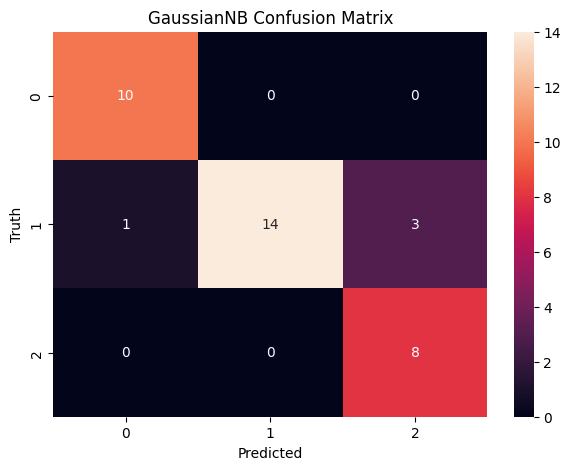

In [12]:
plt.figure(figsize=(7,5))

sn.heatmap(
    cm_g,
    annot=True,
    fmt='d'
)

plt.xlabel('Predicted')

plt.ylabel('Truth')

plt.title('GaussianNB Confusion Matrix')

plt.show()

In [13]:
model_m = MultinomialNB()

model_m.fit(X_train, y_train)

multinomial_accuracy = model_m.score(
    X_test,
    y_test
)

print("\nMultinomialNB Accuracy:")

print(multinomial_accuracy)


MultinomialNB Accuracy:
0.8333333333333334


In [14]:
y_predicted_m = model_m.predict(X_test)

print("\nMultinomial Predictions:")

print(y_predicted_m)
cm_m = confusion_matrix(
    y_test,
    y_predicted_m
)

print("\nMultinomial Confusion Matrix:")

print(cm_m)


Multinomial Predictions:
[1 1 1 1 0 1 1 1 2 0 0 1 0 1 1 2 1 1 1 2 0 2 0 0 1 2 2 2 2 1 2 2 0 2 1 0]

Multinomial Confusion Matrix:
[[ 8  2  0]
 [ 1 14  3]
 [ 0  0  8]]


In [15]:
print("MultinomialNB Accuracy:")

print(multinomial_accuracy)
sample_prediction = model_g.predict([
    X_test.iloc[0]
])

print("\nSample Prediction using GaussianNB:")

print(sample_prediction)


sample_prediction2 = model_m.predict([
    X_test.iloc[1]
])

print("\nSample Prediction using MultinomialNB:")

print(sample_prediction2)

MultinomialNB Accuracy:
0.8333333333333334

Sample Prediction using GaussianNB:
[1]

Sample Prediction using MultinomialNB:
[1]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but GaussianNB was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MultinomialNB was fitted with feature names
  warnings.warn(
